In [91]:
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import pandas as pd


In [92]:
df = pd.read_csv("Summary_of_Weather.csv")


C:\Users\PC\AppData\Local\Temp\ipykernel_23988\1928800348.py:1: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Summary_of_Weather.csv")


In [93]:
df.tail()


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
119035,82506,1945-12-27,0,NaN,28.333333,18.333333,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119036,82506,1945-12-28,9.906,NaN,29.444444,18.333333,23.888889,0.0,1.0,45,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
119037,82506,1945-12-29,0,NaN,28.333333,18.333333,23.333333,0.0,1.0,45,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
119038,82506,1945-12-30,0,NaN,28.333333,18.333333,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119039,82506,1945-12-31,0,NaN,29.444444,17.222222,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
df

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119035,82506,1945-12-27,0,NaN,28.333333,18.333333,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119036,82506,1945-12-28,9.906,NaN,29.444444,18.333333,23.888889,0.0,1.0,45,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
119037,82506,1945-12-29,0,NaN,28.333333,18.333333,23.333333,0.0,1.0,45,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
119038,82506,1945-12-30,0,NaN,28.333333,18.333333,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-

In [96]:
df.drop(["DR", "SPD", "FT","FB","FTI","ITH","PGT","SD3","RHX","RHN","RVG","WTE"], axis=1, inplace=True)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 19 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  MAX          118566 non-null  float64
 14  MIN          118572 non-null  float64
 15  MEA          118542 non-null  float64
 16  SNF          117877 non-null  object 
 17  SND          5563 non-null    float64
 18  TSHDSBRSGF   34237 non-n

In [98]:
df.drop(["MAX","MIN","MEA"], axis=1, inplace=True)

In [99]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  SNF          117877 non-null  object 
 14  SND          5563 non-null    float64
 15  TSHDSBRSGF   34237 non-null   object 
dtypes: float64(5), int64(4), object(7)
memory usage: 14.5+ MB


In [100]:
df.corr

<bound method DataFrame.corr of           STA        Date Precip  WindGustSpd    MaxTemp    MinTemp  \
0       10001    1942-7-1  1.016          NaN  25.555556  22.222222   
1       10001    1942-7-2      0          NaN  28.888889  21.666667   
2       10001    1942-7-3   2.54          NaN  26.111111  22.222222   
3       10001    1942-7-4   2.54          NaN  26.666667  22.222222   
4       10001    1942-7-5      0          NaN  26.666667  21.666667   
...       ...         ...    ...          ...        ...        ...   
119035  82506  1945-12-27      0          NaN  28.333333  18.333333   
119036  82506  1945-12-28  9.906          NaN  29.444444  18.333333   
119037  82506  1945-12-29      0          NaN  28.333333  18.333333   
119038  82506  1945-12-30      0          NaN  28.333333  18.333333   
119039  82506  1945-12-31      0          NaN  29.444444  17.222222   

         MeanTemp Snowfall PoorWeather  YR  MO  DA  PRCP  SNF  SND TSHDSBRSGF  
0       23.888889      0.0         

In [101]:
df["Snowfall"]

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
119035    0.0
119036    0.0
119037    0.0
119038    0.0
119039    0.0
Name: Snowfall, Length: 119040, dtype: object

In [102]:
df[["Date", "Precip", "STA", "WindGustSpd"]]

,Date,Precip,STA,WindGustSpd
0,1942-7-1,1.016,10001,NaN
1,1942-7-2,0,10001,NaN
2,1942-7-3,2.54,10001,NaN
3,1942-7-4,2.54,10001,NaN
4,1942-7-5,0,10001,NaN
...,...,...,...,...
119035,1945-12-27,0,82506,NaN
119036,1945-12-28,9.906,82506,NaN
119037,1945-12-29,0,82506,NaN
119038,1945-12-30,0,82506,NaN


In [103]:
df.drop(["WindGustSpd"], axis=1, inplace=True)


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   MaxTemp      119040 non-null  float64
 4   MinTemp      119040 non-null  float64
 5   MeanTemp     119040 non-null  float64
 6   Snowfall     117877 non-null  object 
 7   PoorWeather  34237 non-null   object 
 8   YR           119040 non-null  int64  
 9   MO           119040 non-null  int64  
 10  DA           119040 non-null  int64  
 11  PRCP         117108 non-null  object 
 12  SNF          117877 non-null  object 
 13  SND          5563 non-null    float64
 14  TSHDSBRSGF   34237 non-null   object 
dtypes: float64(4), int64(4), object(7)
memory usage: 13.6+ MB


In [105]:
df.drop(["TSHDSBRSGF"], axis=1, inplace=True)


In [106]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   MaxTemp      119040 non-null  float64
 4   MinTemp      119040 non-null  float64
 5   MeanTemp     119040 non-null  float64
 6   Snowfall     117877 non-null  object 
 7   PoorWeather  34237 non-null   object 
 8   YR           119040 non-null  int64  
 9   MO           119040 non-null  int64  
 10  DA           119040 non-null  int64  
 11  PRCP         117108 non-null  object 
 12  SNF          117877 non-null  object 
 13  SND          5563 non-null    float64
dtypes: float64(4), int64(4), object(6)
memory usage: 12.7+ MB


In [107]:
df.drop(["STA"], axis=1, inplace=True)

In [108]:
df.isnull().sum()


Date                0
Precip              0
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
SNF              1163
SND            113477
dtype: int64

In [109]:
df.drop(["SND"], axis=1, inplace=True)

In [110]:
df.drop(["PoorWeather"], axis=1, inplace=True)



In [111]:
df.drop(["Date"], axis=1, inplace=True)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Precip    119040 non-null  object 
 1   MaxTemp   119040 non-null  float64
 2   MinTemp   119040 non-null  float64
 3   MeanTemp  119040 non-null  float64
 4   Snowfall  117877 non-null  object 
 5   YR        119040 non-null  int64  
 6   MO        119040 non-null  int64  
 7   DA        119040 non-null  int64  
 8   PRCP      117108 non-null  object 
 9   SNF       117877 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 9.1+ MB


In [113]:
df.describe()

,MaxTemp,MinTemp,MeanTemp,YR,MO,DA
count,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000
mean,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530
std,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541
min,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000
25%,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000
50%,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000
75%,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000
max,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000


In [114]:
df[["MeanTemp","Precip","Snowfall","SNF","PRCP"]]

,MeanTemp,Precip,Snowfall,SNF,PRCP
0,23.888889,1.016,0.0,0.0,0.04
1,25.555556,0,0.0,0.0,0
2,24.444444,2.54,0.0,0.0,0.1
3,24.444444,2.54,0.0,0.0,0.1
4,24.444444,0,0.0,0.0,0
...,...,...,...,...,...
119035,23.333333,0,0.0,0.0,0
119036,23.888889,9.906,0.0,0.0,0.39
119037,23.333333,0,0.0,0.0,0
119038,23.333333,0,0.0,0.0,0


In [115]:
df.drop(["SNF"], axis=1, inplace=True)

In [116]:
df.isnull().sum()


Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall    1163
YR             0
MO             0
DA             0
PRCP        1932
dtype: int64

In [117]:


df["Snowfall"] = (
    df["Snowfall"]
    .replace("#VALUE!", np.nan)   # bozuk değer
)

df["Snowfall"] = pd.to_numeric(
    df["Snowfall"],
    errors="coerce"               # sayı olmayan → NaN
)

df["Snowfall"] = df["Snowfall"].fillna(0.0)


In [118]:
df["Snowfall"].value_counts()


Snowfall
0.00     116897
5.08        534
2.54        339
7.62        330
10.16       205
12.70        92
20.32        83
17.78        78
15.24        74
22.86        69
25.40        68
27.94        40
30.48        31
45.72        25
50.80        24
48.26        22
35.56        20
33.02        15
60.96        13
38.10        11
66.04        11
53.34        10
43.18        10
63.50         7
55.88         6
40.64         6
76.20         5
58.42         5
81.28         4
78.74         2
73.66         1
86.36         1
83.82         1
68.58         1
Name: count, dtype: int64

In [119]:
df["PRCP"].value_counts()


PRCP
0       62335
T       16753
0.01     3389
0.02     2909
0.03     2015
        ...  
4.87        1
4.2         1
4.98        1
4.88        1
6.34        1
Name: count, Length: 540, dtype: int64

In [120]:
import numpy as np
import pandas as pd

df["PRCP"] = (
    df["PRCP"]
    .replace("T", 0)          # Trace → 0
)

df["PRCP"] = pd.to_numeric(
    df["PRCP"],
    errors="coerce"           # sayı olmayan → NaN
)

df["PRCP"] = df["PRCP"].fillna(0.0)


In [121]:
df["PRCP"].value_counts()


PRCP
0.00    81020
0.01     3389
0.02     2909
0.03     2015
0.04     1639
        ...  
4.87        1
4.20        1
4.98        1
4.88        1
6.34        1
Name: count, Length: 539, dtype: int64

In [122]:
df["PRCP"].value_counts()


PRCP
0.00    81020
0.01     3389
0.02     2909
0.03     2015
0.04     1639
        ...  
4.87        1
4.20        1
4.98        1
4.88        1
6.34        1
Name: count, Length: 539, dtype: int64

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Precip    119040 non-null  object 
 1   MaxTemp   119040 non-null  float64
 2   MinTemp   119040 non-null  float64
 3   MeanTemp  119040 non-null  float64
 4   Snowfall  119040 non-null  float64
 5   YR        119040 non-null  int64  
 6   MO        119040 non-null  int64  
 7   DA        119040 non-null  int64  
 8   PRCP      119040 non-null  float64
dtypes: float64(5), int64(3), object(1)
memory usage: 8.2+ MB


In [124]:
df["Precip"].value_counts()

Precip
0          64267
T          16753
0.254       3389
0.508       2909
0.762       2015
           ...  
123.698        1
106.68         1
126.492        1
123.952        1
161.036        1
Name: count, Length: 540, dtype: int64

In [125]:
df = df.drop("Precip", axis=1)


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   MaxTemp   119040 non-null  float64
 1   MinTemp   119040 non-null  float64
 2   MeanTemp  119040 non-null  float64
 3   Snowfall  119040 non-null  float64
 4   YR        119040 non-null  int64  
 5   MO        119040 non-null  int64  
 6   DA        119040 non-null  int64  
 7   PRCP      119040 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 7.3 MB


In [127]:
df.corr()

,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP
MaxTemp,1.000000,0.878384,0.969048,-0.322013,0.039585,0.031346,-0.005130,0.004457
MinTemp,0.878384,1.000000,0.965425,-0.307854,-0.020733,0.069078,-0.002576,0.088455
MeanTemp,0.969048,0.965425,1.000000,-0.323671,0.010681,0.050769,-0.004153,0.047061
Snowfall,-0.322013,-0.307854,-0.323671,1.000000,-0.001020,-0.044540,-0.000244,-0.011043
YR,0.039585,-0.020733,0.010681,-0.001020,1.000000,-0.144360,-0.011196,0.008951
MO,0.031346,0.069078,0.050769,-0.044540,-0.144360,1.000000,0.006563,0.037802
DA,-0.005130,-0.002576,-0.004153,-0.000244,-0.011196,0.006563,1.000000,0.000595
PRCP,0.004457,0.088455,0.047061,-0.011043,0.008951,0.037802,0.000595,1.000000


In [128]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop("MeanTemp", axis=1)

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif


,feature,VIF
0,MaxTemp,48.992926
1,MinTemp,25.510790
2,Snowfall,1.129074
3,YR,20.614225
4,MO,4.825084
5,DA,4.214434
6,PRCP,1.125712


In [149]:
X = df[["Snowfall", "PRCP", "MO", "DA"]]
y = df["MeanTemp"]


In [150]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

KeyError: 'Date'

In [151]:
df = df[[
    "Date",
    "MeanTemp",
    "Snowfall",
    "PRCP",
    "MO",
    "DA"
]].dropna()


KeyError: "['Date'] not in index"

In [152]:
X = df[["Snowfall", "PRCP", "MO", "DA"]]
y = df["MeanTemp"]


In [ ]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [147]:

model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [148]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 5.55003762640433
MSE : 60.7543453879827
RMSE: 7.794507385844387
R²  : 0.10566111435194947


In [41]:
df.drop(["MaxTemp","MinTemp"], axis=1, inplace=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   MeanTemp  119040 non-null  float64
 1   Snowfall  119040 non-null  float64
 2   YR        119040 non-null  int64  
 3   MO        119040 non-null  int64  
 4   DA        119040 non-null  int64  
 5   PRCP      119040 non-null  float64
 6   SND       5563 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 6.4 MB


In [43]:
X = df[["Snowfall", "PRCP", "MO", "DA"]]
y = df["MeanTemp"]


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [69]:

model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 5.54091622012161
MSE : 60.66883277571217
RMSE: 7.789020013821519
R²  : 0.10691990915713578


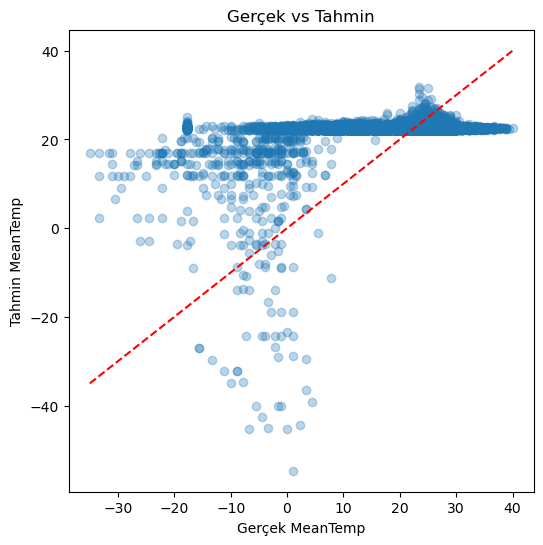

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Gerçek MeanTemp")
plt.ylabel("Tahmin MeanTemp")
plt.title("Gerçek vs Tahmin")
plt.show()

In [72]:
X = df[["Snowfall", "PRCP", "MO", "DA"]]
y = df["MeanTemp"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
poly_model.fit(X_train, y_train)

,steps,"[('poly', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = poly_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Polynomial Regression Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)



Polynomial Regression Results
MAE : 5.174738143773588
RMSE: 7.266889754112904
R²  : 0.22264049799361352


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])


In [51]:
from sklearn.model_selection import GroupKFold

groups = df["YR"]  # yıl bazlı ayır

gkf = GroupKFold(n_splits=5)

cv_scores = cross_val_score(
    poly_model,
    X,
    y,
    cv=gkf,
    groups=groups,
    scoring="r2"
)

print("GroupKFold R²:", cv_scores)
print("Mean:", cv_scores.mean())


NameError: name 'cross_val_score' is not defined

In [76]:
X = df[["Snowfall", "PRCP", "MO", "DA"]]
y = df["MeanTemp"]


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

poly_model_mo = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

poly_model_mo.fit(X_train, y_train)
y_pred = poly_model_mo.predict(X_test)


In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))


MAE : 5.174738143773588
RMSE: 7.266889754112904
R²  : 0.22264049799361352


In [80]:
df["MO"].unique()


array([ 7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6])

In [81]:
df["MO"].value_counts()


MO
12    11043
8     10547
10    10501
11    10408
7     10235
9     10122
5     10098
6      9837
4      9507
3      9447
1      8939
2      8356
Name: count, dtype: int64

In [84]:
X = df[["Snowfall", "PRCP", "MO", "DA"]]
y = df["MeanTemp"]




In [85]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


In [86]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

ts_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])


In [87]:
ts_model.fit(X_train, y_train)


,steps,"[('poly', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [157]:
X = df[["Snowfall", "PRCP", "MO", "DA"]]
y = df["MeanTemp"]


In [158]:
df = df.sort_values(["MO", "DA"])


In [159]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


In [160]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

ts_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])


In [161]:
ts_model.fit(X_train, y_train)


,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [162]:
y_pred = ts_model.predict(X_test)


In [163]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))


MAE : 6.147413734568509
RMSE: 9.921951404030384
R²  : -0.24168409830139703


In [164]:
df["MO_sin"] = np.sin(2*np.pi*df["MO"]/12)
df["MO_cos"] = np.cos(2*np.pi*df["MO"]/12)


In [165]:
import numpy as np

df["MO_sin"] = np.sin(2 * np.pi * df["MO"] / 12)
df["MO_cos"] = np.cos(2 * np.pi * df["MO"] / 12)


In [166]:
X = df[[
    "Snowfall",
    "PRCP",
    "DA",
    "MO_sin",
    "MO_cos"
]]

y = df["MeanTemp"]


In [167]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


In [169]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_ts_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])


In [170]:
poly_ts_model.fit(X_train, y_train)


,steps,"[('poly', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [171]:
y_pred = poly_ts_model.predict(X_test)


In [172]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Polynomial Time Series Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Polynomial Time Series Results
MAE : 5.904693675193233
RMSE: 7.8180256765095795
R²  : 0.2290768043176593


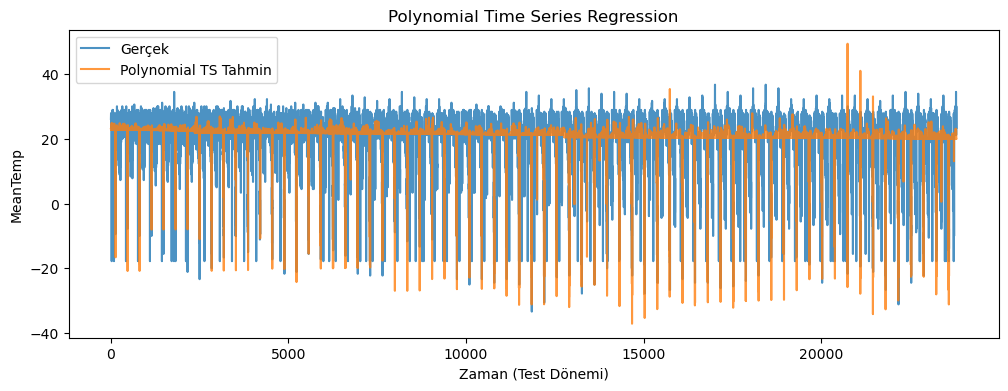

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Gerçek", alpha=0.8)
plt.plot(y_pred, label="Polynomial TS Tahmin", alpha=0.8)
plt.legend()
plt.title("Polynomial Time Series Regression")
plt.xlabel("Zaman (Test Dönemi)")
plt.ylabel("MeanTemp")
plt.show()
